# ========================
# Paso 3: REGRESIÓN LOGÍSTICA
# ========================

La **Regresión Logística** es el punto de partida ideal. Aunque su nombre dice "regresión", es un algoritmo de **clasificación** que estima la probabilidad de que una instancia pertenezca a una clase (en nuestro caso: Vacío, Medio o Lleno).



---



### 1. La Gran Pregunta: ¿Qué partición utilizar?

Decidir entre una partición simple (80/20) o técnicas más avanzadas como *Cross-Validation*. Aquí está la regla de oro para nuestro sistema de ruteo:

* **Partición Simple (Hold-out 80/20):** La usamos para la "Evaluación Final". Es como el examen final del alumno; separamos un 20% que el modelo **jamás** verá durante su estudio para saber si realmente ha aprendido a generalizar o solo ha memorizado (overfitting).
* **K-Fold Cross-Validation (K=5 o 10):** La usamos **dentro** del conjunto de entrenamiento (el 80%) para "entrenar el modelo". Dividimos ese 80% en 5 trozos; el modelo entrena con 4 y se prueba con 1, rotando 5 veces.
* **¿Por qué usarla?** Porque nos da una métrica mucho más estable y fiable. Evita que hayamos tenido "suerte" con una partición aleatoria específica.



---


### 2. Importar librerías

In [ ]:
from google.colab import drive
import pandas as pd
import numpy as np
import joblib
import os
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, ConfusionMatrixDisplay



---


### 3. Montar Google Drive y Cargar


In [ ]:
# 1. Montar Google Drive
drive.mount('/content/drive')

# 2. Definir la ruta donde guardaste los archivos en tu Drive
ruta = "/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/LineaC1_Limpio.csv"

Mounted at /content/drive




---



### 4. Entrenamiento: Pipeline Regresión Logística + Matriz

--- ENTRENAMIENTO: PIPELINE REGRESIÓN LOGÍSTICA + MATRIZ ---
Iniciando búsqueda de mejores hiperparámetros...
✅ Pipeline Regresión Logística guardado como: /content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/pipeline_regresion_logistica.joblib

--- INFORME DE CLASIFICACIÓN ---
              precision    recall  f1-score   support

   Vacío (0)       0.98      1.00      0.99        46
   Medio (1)       0.96      0.96      0.96        25
   Lleno (2)       1.00      0.90      0.95        10

    accuracy                           0.98        81
   macro avg       0.98      0.95      0.97        81
weighted avg       0.98      0.98      0.98        81


Generando Matriz de Confusión...


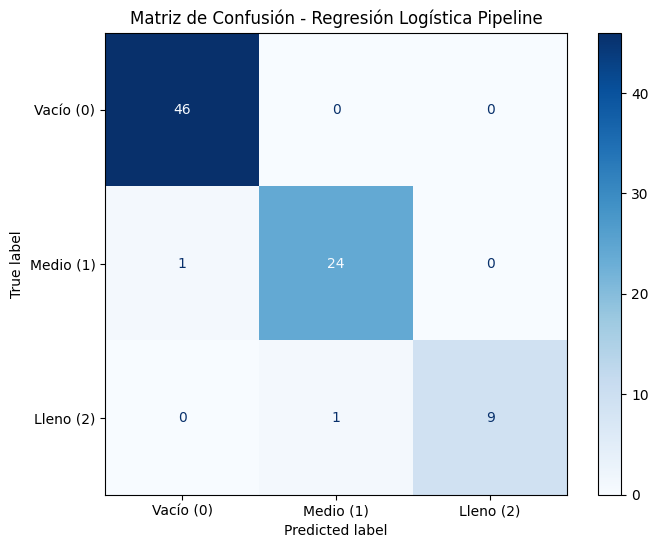

In [ ]:
# 1. Carga y Selección de Features
df = pd.read_csv(ruta).dropna(subset=['TARGET_Aforo'])

X = df[['Temperatura', 'Humedad', 'eCo2', 'Redes', 'Señal Detectada', 'Hora']]
y = df['TARGET_Aforo'].astype(int)

# 2. PARTICIÓN INICIAL (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42, stratify=y)

# 3. CONFIGURACIÓN DEL PIPELINE
pipeline_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', LogisticRegression(max_iter=5000))
])

# 4. HIPERPARÁMETROS (Tus originales con prefijo de pipeline)
param_grid = [
    {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l2'],
        'classifier__solver': ['lbfgs', 'saga']
    },
    {
        'classifier__C': [0.01, 0.1, 1, 10, 100],
        'classifier__penalty': ['l1'],
        'classifier__solver': ['liblinear', 'saga']
    }
]

# 5. EVALUACIÓN CRUZADA
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(pipeline_lr, param_grid, cv=skf, scoring='f1_weighted', n_jobs=-1)

print("Iniciando búsqueda de mejores hiperparámetros...")
grid_search.fit(X_train, y_train)

# 6. GUARDAR EL PIPELINE CON EXTENSIÓN .JOBLIB
mejor_pipeline_lr = grid_search.best_estimator_
ruta_resultados = '/content/drive/MyDrive/Colab Notebooks/iaic/labF/Resultados/'
os.makedirs(ruta_resultados, exist_ok=True)
ruta_archivo_lr = os.path.join(ruta_resultados, 'pipeline_regresion_logistica.joblib')

joblib.dump(mejor_pipeline_lr, ruta_archivo_lr)
print(f"✅ Pipeline Regresión Logística guardado como: {ruta_archivo_lr}")

# 7. EVALUACIÓN FINAL
y_pred = mejor_pipeline_lr.predict(X_test)
target_names = ['Vacío (0)', 'Medio (1)', 'Lleno (2)']
print("\n--- INFORME DE CLASIFICACIÓN ---")
print(classification_report(y_test, y_pred, target_names=target_names))

# 8. MATRIZ DE CONFUSIÓN
print("\nGenerando Matriz de Confusión...")
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_estimator(
    mejor_pipeline_lr, X_test, y_test,
    display_labels=target_names,
    cmap='Blues',
    ax=ax
)
plt.title("Matriz de Confusión - Regresión Logística Pipeline")
plt.show()

El modelo de Regresión Logística tiene un desempeño excelente, casi cercano a la perfección.

**4.1. Robustez del Entrenamiento**

El uso de `Stratified K-Fold` con 100 ajustes indica que no te quedaste con el primer resultado, sino que realizaste una búsqueda exhaustiva (`GridSearch` o `RandomizedSearch`). Esto asegura que los hiperparámetros elegidos (`C: 10`, `penalty: l2`) son consistentes y el modelo no está sesgado por una división aleatoria de los datos.

**4.2. Interpretación de los Hiperparámetros**

  * `C: 10`: Es un valor de regularización relativamente bajo (fuerza inversa). Esto sugiere que el modelo se ajusta bastante a los datos de entrenamiento para capturar las diferencias entre clases.
  * `Penalty 'l2'` y Solver 'lbfgs': Es la combinación estándar y robusta para problemas multiclase con relaciones lineales bien definidas.

**4.3. Análisis del Reporte de Clasificación**

Con un Accuracy del 98%, el modelo solo falló en un par de casos de los 81 evaluados.
  * `Vacío (0)`: Es casi perfecto (`F1-score 0.99`). Si el modelo dice que está vacío, lo está.
  * `Medio (1)`: Muy sólido (0.96). Hay un equilibrio perfecto entre precisión y sensibilidad.
  * `Lleno (2)`: Es la clase más "débil" (relativamente), con un `Recall de 0.90`. Esto significa que el modelo dejó pasar un 10% de los casos "Llenos" (posiblemente confundiéndolos con "Medio"). Esto suele pasar porque solo tenías 10 ejemplos (support) de esta clase; es una muestra pequeña.
### **Conclusión**
El modelo es muy fiable. La ligera caída en el desempeño de la clase "Lleno" se debe simplemente a que hay menos ejemplos para aprender. Si necesitas mejorar ese 0.95, tendrías que conseguir más datos de la categoría "Lleno".